In [64]:
import pandas as pd
import numpy as np
# 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
# 
from special_use_classes import OutlierHandling
import special_use_classes
import importlib
importlib.reload(special_use_classes)
# 
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
mydata = pd.read_csv(r'data\BankChurners.csv')

In [66]:
mydata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [67]:
columns_list = mydata.columns.tolist()
print(columns_list)

['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']


In [68]:
df = mydata.drop(columns=columns_list[-2:])
df = df.drop(columns='CLIENTNUM')

In [69]:
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [70]:
df['Attrition_Flag'].unique().tolist()

['Existing Customer', 'Attrited Customer']

In [71]:
df.isna().sum()

Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

<Axes: >

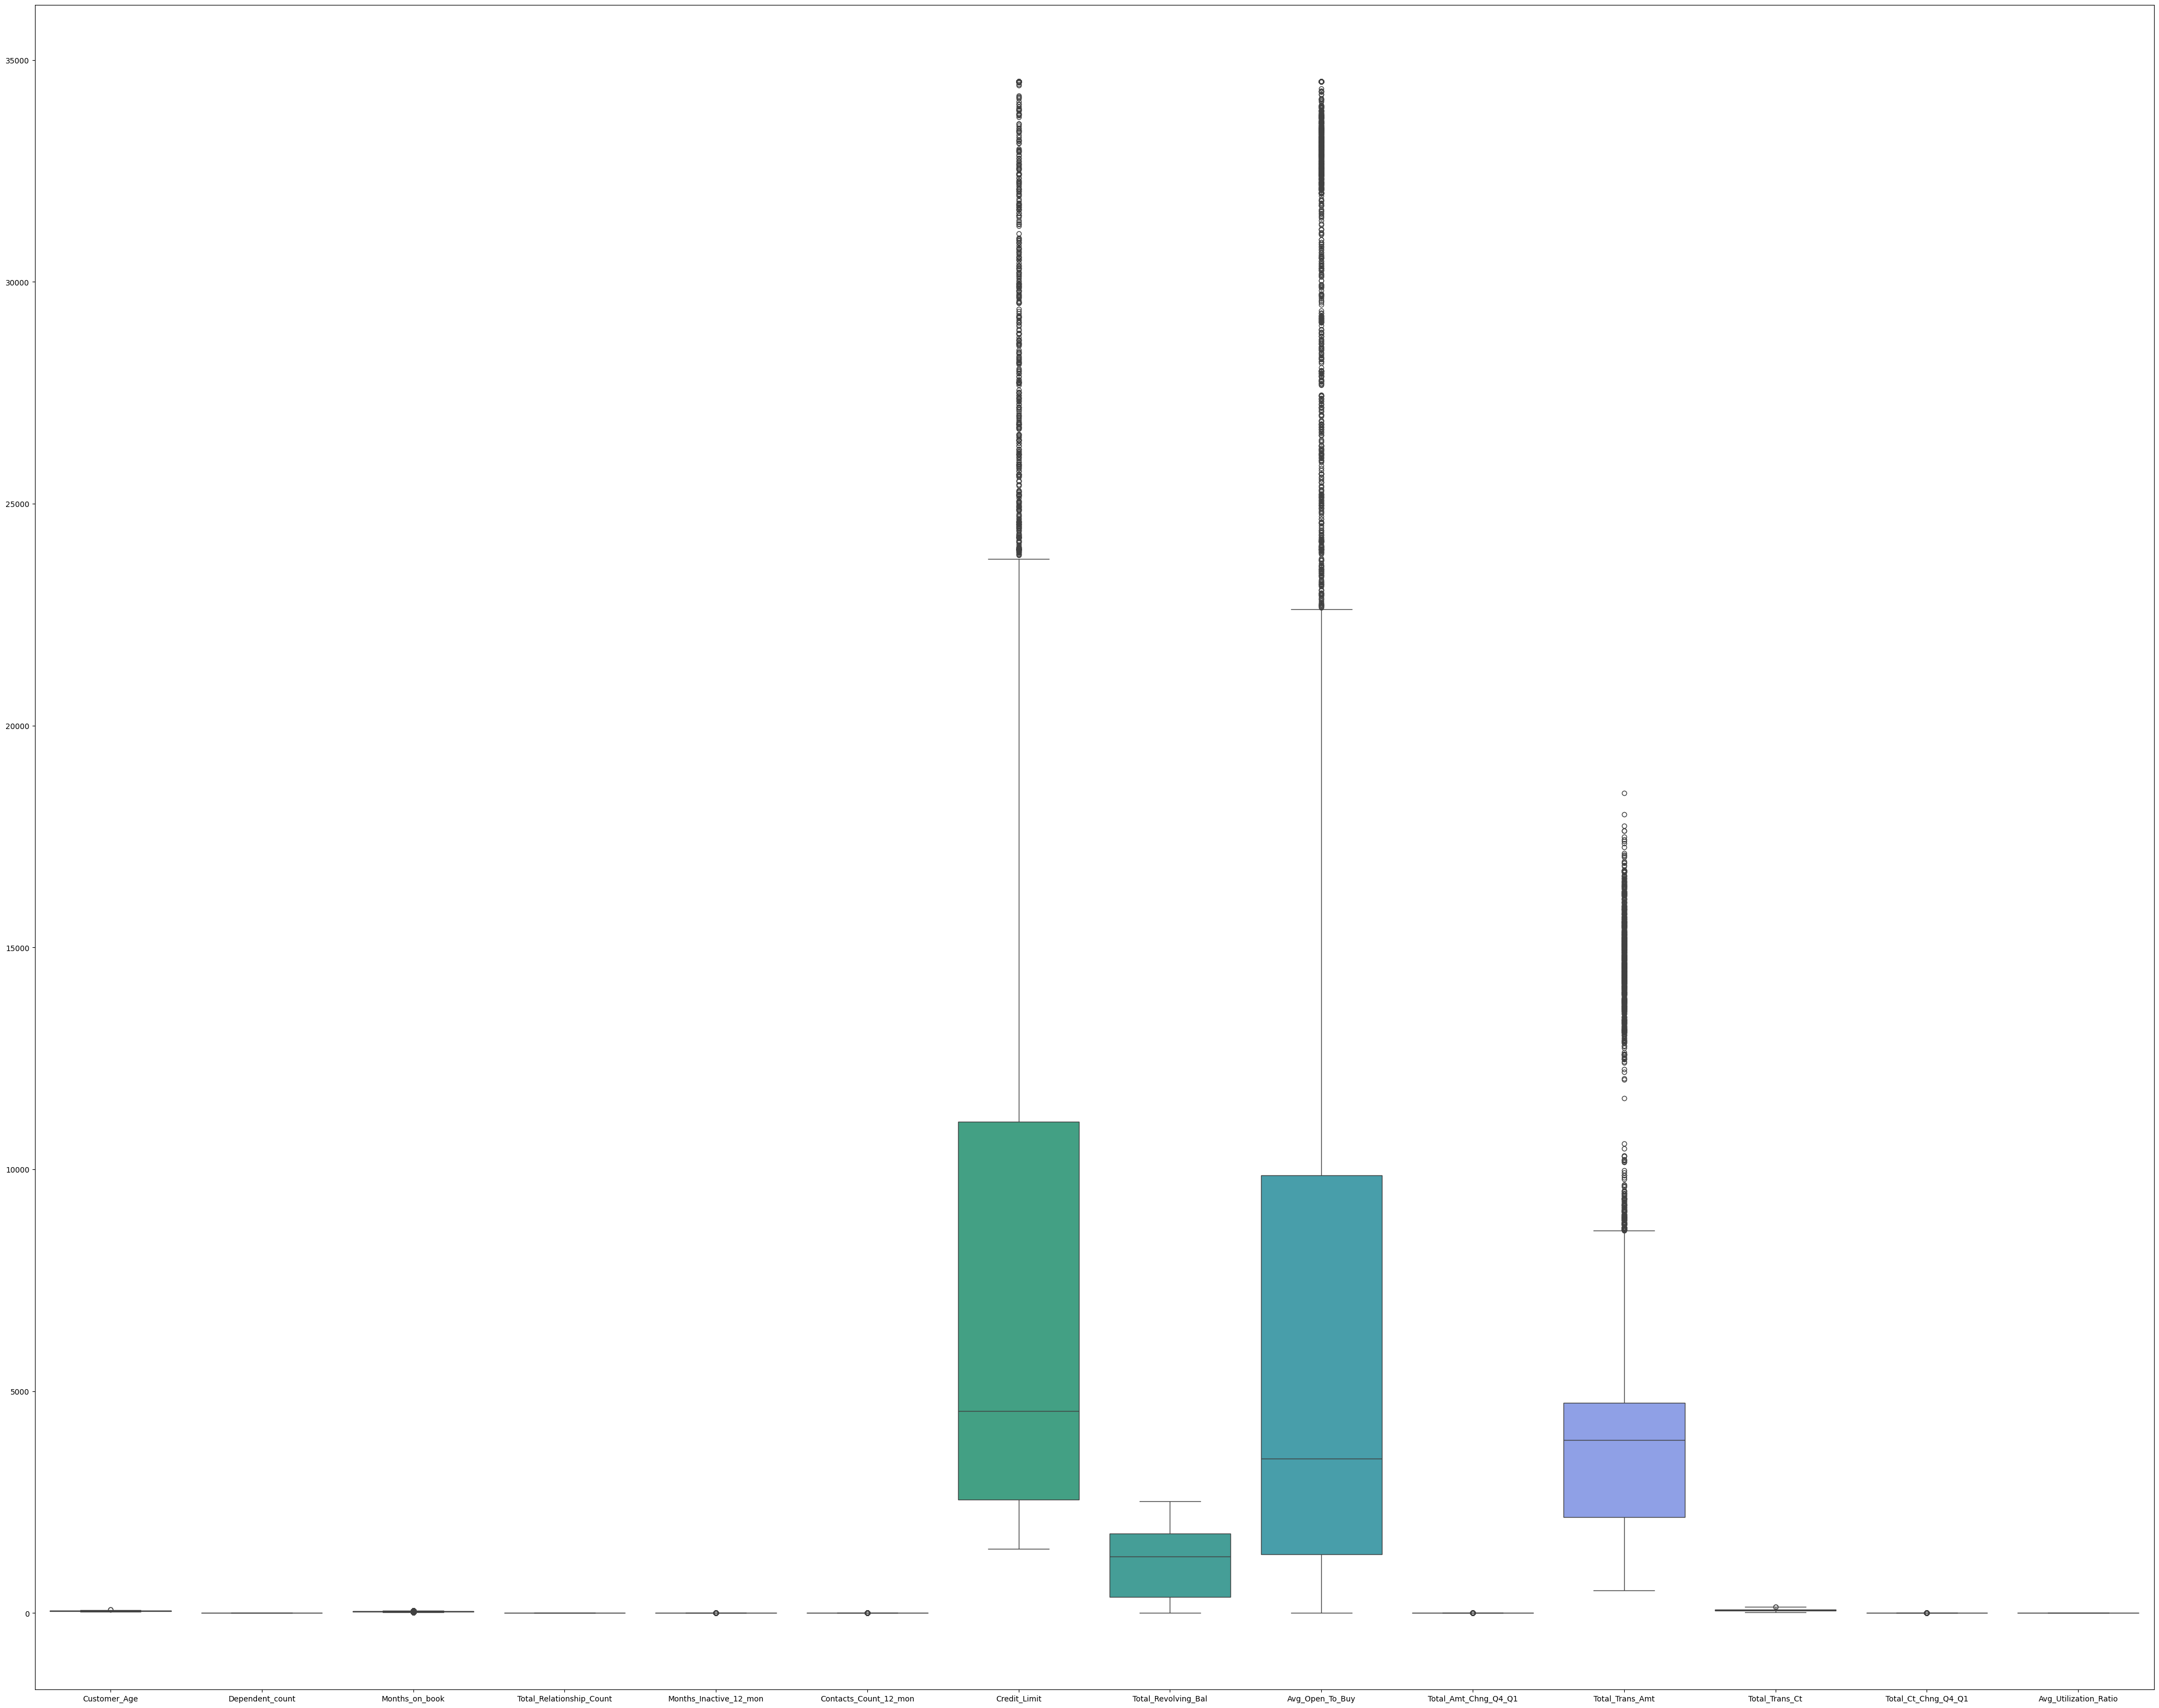

In [72]:
# print(outlier_handler.display_outliers(df))
plt.figure(figsize=(50,40))
sns.boxplot(df)

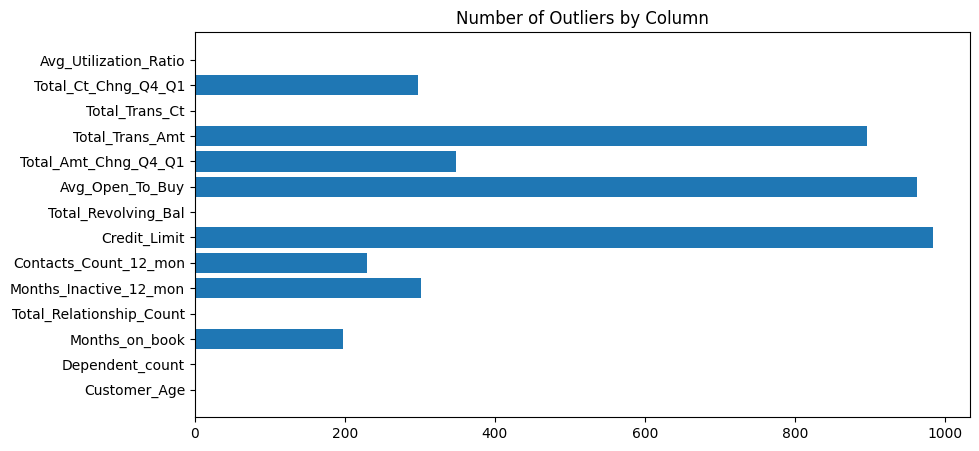

In [73]:
outlier_handler = OutlierHandling()
length_of_hs = []
length_of_ls = []
names = []
for i in df.select_dtypes('number').columns:
    higher, lower = outlier_handler.return_outliers(df[i])
    length_of_hs.append(len(higher))
    length_of_ls.append(len(lower))
    names.append(i)
    # print(f'{i}.\n\n: higher outliers : {len(higher)} \n: lower outliers: {len(lower)}\n_______\n')

plt.figure(figsize=(10,5))
# sns.barplot(x=names, y=length_of_hs)
plt.barh(names, length_of_hs)
plt.title('Number of Outliers by Column')
# plt.gca().invert_yaxis()
# plt.tight_layout()
plt.show()

In [74]:
df_cleaned = df

for i in df.select_dtypes('number').columns:
    df_cleaned[i] = outlier_handler.fit_transform_IQR(df[i])


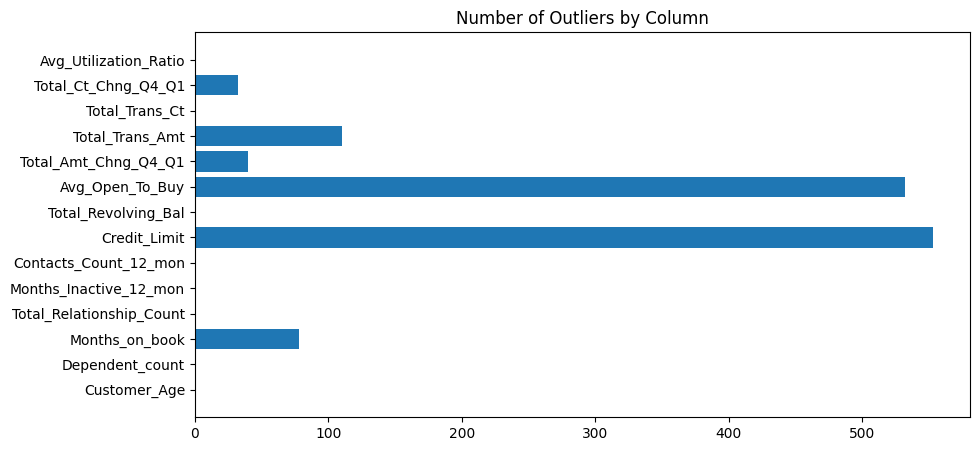

In [75]:
outlier_handler = OutlierHandling()
length_of_hs = []
length_of_ls = []
names = []
for i in df_cleaned.select_dtypes('number').columns:
    higher, lower = outlier_handler.return_outliers(df[i])
    length_of_hs.append(len(higher))
    length_of_ls.append(len(lower))
    names.append(i)
    # print(f'{i}.\n\n: higher outliers : {len(higher)} \n: lower outliers: {len(lower)}\n_______\n')

plt.figure(figsize=(10,5))
# sns.barplot(x=names, y=length_of_hs)
plt.barh(names, length_of_hs)
plt.title('Number of Outliers by Column')
# plt.gca().invert_yaxis()
# plt.tight_layout()
plt.show()

In [76]:

for i in df.select_dtypes('number').columns:
    df_cleaned[i] = outlier_handler.fit_transform_IQR(df_cleaned[i])


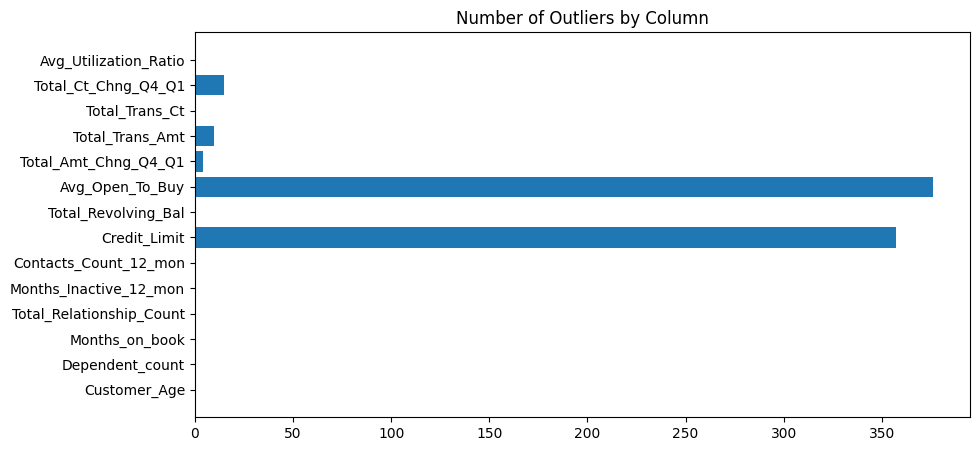

In [77]:
outlier_handler = OutlierHandling()
length_of_hs = []
length_of_ls = []
names = []
for i in df_cleaned.select_dtypes('number').columns:
    higher, lower = outlier_handler.return_outliers(df[i])
    length_of_hs.append(len(higher))
    length_of_ls.append(len(lower))
    names.append(i)
    # print(f'{i}.\n\n: higher outliers : {len(higher)} \n: lower outliers: {len(lower)}\n_______\n')

plt.figure(figsize=(10,5))
# sns.barplot(x=names, y=length_of_hs)
plt.barh(names, length_of_hs)
plt.title('Number of Outliers by Column')
# plt.gca().invert_yaxis()
# plt.tight_layout()
plt.show()

In [78]:
df_final = df_cleaned
df_final.dropna(inplace=True)

In [79]:
df_final.count()

Attrition_Flag              6094
Customer_Age                6094
Gender                      6094
Dependent_count             6094
Education_Level             6094
Marital_Status              6094
Income_Category             6094
Card_Category               6094
Months_on_book              6094
Total_Relationship_Count    6094
Months_Inactive_12_mon      6094
Contacts_Count_12_mon       6094
Credit_Limit                6094
Total_Revolving_Bal         6094
Avg_Open_To_Buy             6094
Total_Amt_Chng_Q4_Q1        6094
Total_Trans_Amt             6094
Total_Trans_Ct              6094
Total_Ct_Chng_Q4_Q1         6094
Avg_Utilization_Ratio       6094
dtype: int64

In [80]:
newdf = pd.get_dummies(df)

In [81]:
newdf.head()

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,...,Income_Category_$120K +,Income_Category_$40K - $60K,Income_Category_$60K - $80K,Income_Category_$80K - $120K,Income_Category_Less than $40K,Income_Category_Unknown,Card_Category_Blue,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
10,42.0,5,31.0,5,3.0,2.0,6748.0,1467,5281.0,0.831,...,True,False,False,False,False,False,True,False,False,False
19,45.0,2,37.0,6,1.0,2.0,14470.0,1157,13313.0,0.966,...,False,False,False,False,False,True,True,False,False,False
21,62.0,0,49.0,2,3.0,3.0,1438.3,0,1438.3,1.047,...,False,False,False,False,True,False,True,False,False,False
23,47.0,4,36.0,3,3.0,2.0,2492.0,1560,932.0,0.573,...,False,False,False,False,True,False,True,False,False,False
24,54.0,2,42.0,4,2.0,3.0,12217.0,0,12217.0,1.075,...,False,False,False,True,False,False,True,False,False,False


In [82]:
newdf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6094 entries, 10 to 10089
Data columns (total 39 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Customer_Age                      6094 non-null   float64
 1   Dependent_count                   6094 non-null   int64  
 2   Months_on_book                    6094 non-null   float64
 3   Total_Relationship_Count          6094 non-null   int64  
 4   Months_Inactive_12_mon            6094 non-null   float64
 5   Contacts_Count_12_mon             6094 non-null   float64
 6   Credit_Limit                      6094 non-null   float64
 7   Total_Revolving_Bal               6094 non-null   int64  
 8   Avg_Open_To_Buy                   6094 non-null   float64
 9   Total_Amt_Chng_Q4_Q1              6094 non-null   float64
 10  Total_Trans_Amt                   6094 non-null   float64
 11  Total_Trans_Ct                    6094 non-null   float64
 12  Total_Ct_

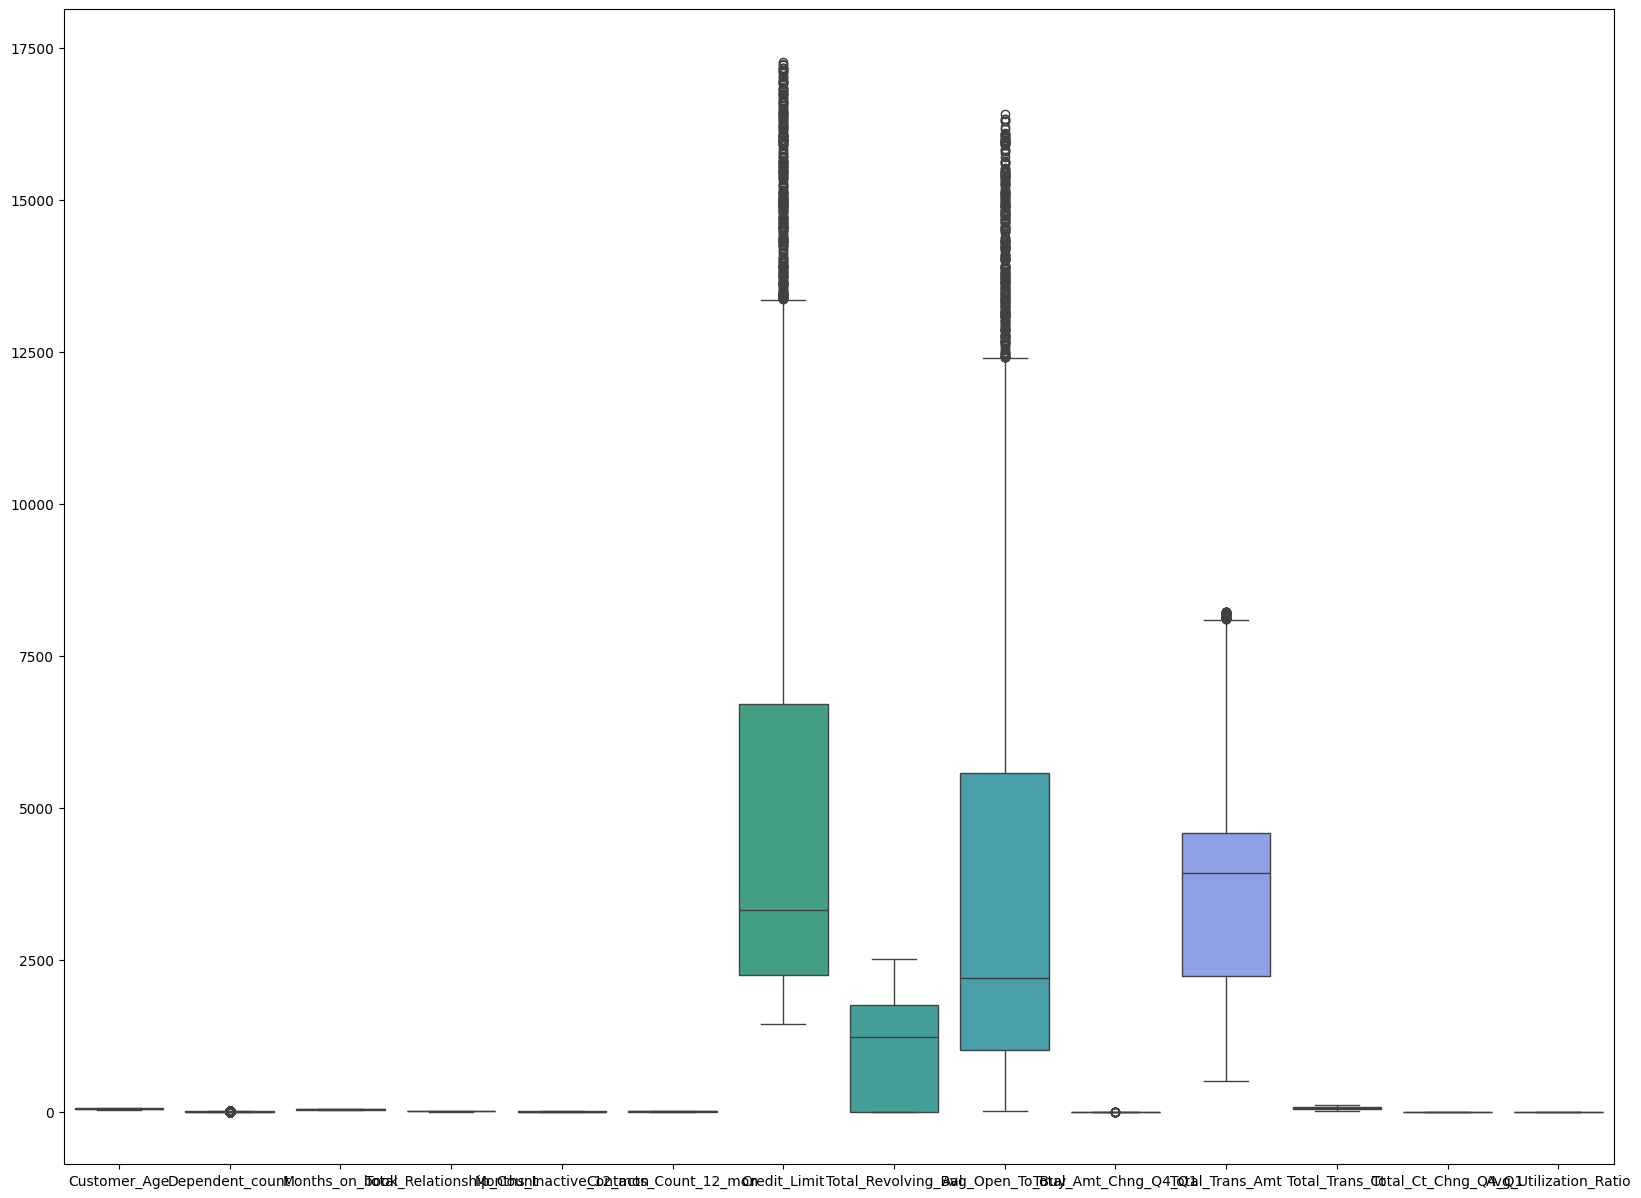

In [83]:
plt.figure(figsize=(20,15))
sns.boxplot(df_final)
plt.show()